# 🎓PROJET: CUSTOMER CHURN PREDICTION
##  GENERAL VS HIGH-PAYING CUSTOMERS

**Author:** Chaïmae Fekhar   
**Dataset:** Telco Customer Churn  
**Date:** 25/01/2026

---

## Project Overview

This notebook analyzes customer churn using a clean telecom dataset.  
We compare general customers with high-paying customers, using EDA, visualizations, and machine learning models to uncover patterns and predict churn.

---

## Notebook Structure

1. **Data Loading**  
2. **Exploratory Data Analysis (EDA)**  
3. **Data Visualization**  
4. **High-Paying Customers Analysis**  
5. **Data Preprocessing**  
6. **Train-Test Split**  
7. **Model Training**  
8. **Model Evaluation**  
9. **Feature Importance & Interpretation**  
10. **Conclusion & Recommendations**

## Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# Optional: warnings
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set(style="whitegrid")

## Data Loading

In [2]:
# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Show first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Exploratory Data Analysis (EDA)

In [3]:
df.shape


(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN




TotalCharges shows the total amount a customer has paid since starting their contract.  
Some values are stored as strings for new customers with zero tenure, leaving empty cells.  

I will convert this column to numeric and fill missing values with 0 so it can be used safely in analysis and machine learning models.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

## Data Visualization

1. Churn Distribution

This plot shows the distribution of churned and non-churned customers.

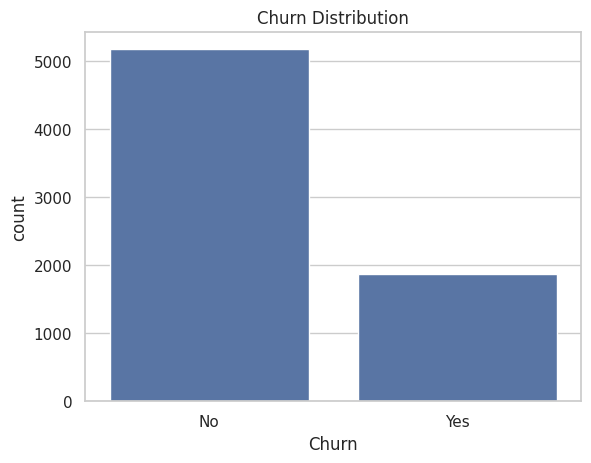

In [8]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

We observe that most customers did not churn.
This indicates a class imbalance in the target variable.

2. Churn vs Contract Type

This plot analyzes the relationship between contract type and customer churn.

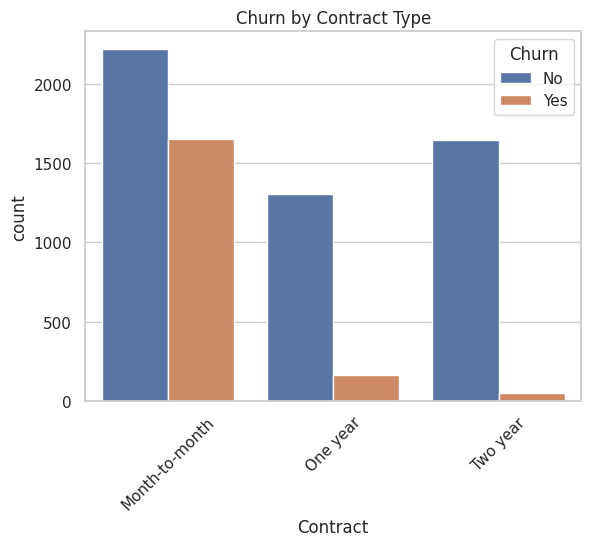

In [9]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.xticks(rotation=45)
plt.show()

### Interpretation

The plot shows a strong relationship between contract type and customer churn.
Customers with month-to-month contracts have the highest churn rate, while those
with one-year and especially two-year contracts are much more likely to stay.
This indicates that longer contract durations significantly reduce customer churn.

3. Churn vs Monthly Charges

This plot shows the relationship between customers' monthly charges and their churn status.



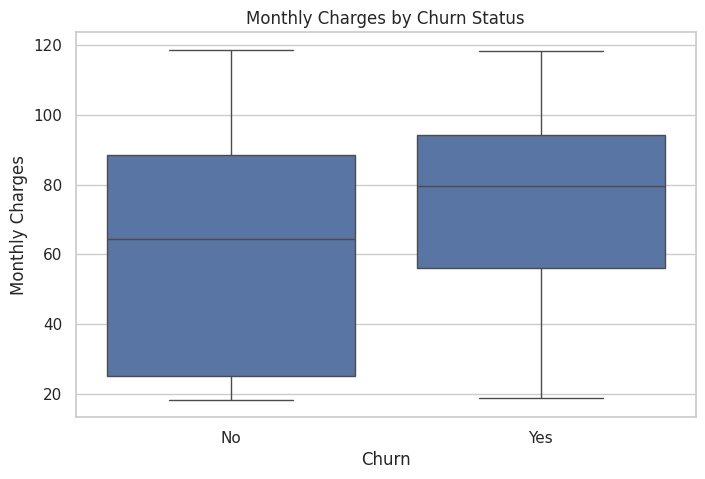

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('Monthly Charges by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.show()


From the boxplot, we can see that customers who churn (Yes) tend to have higher monthly charges compared to those who stay (No).  
This indicates that monthly charges could be an important factor in predicting churn.


4. Churn vs Tenure

This plot examines the relationship between customers' tenure (duration with the company) and churn status.

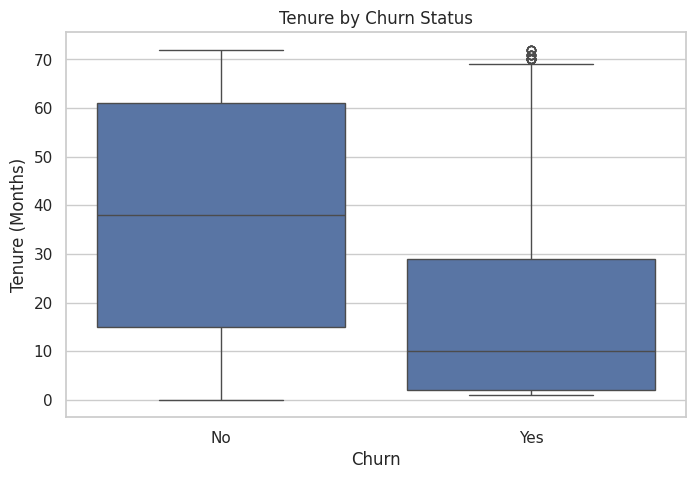

In [11]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Churn', y='tenure')
plt.title('Tenure by Churn Status')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

### Analysis

Customers who churn (Yes) generally have shorter tenure compared to those who stay (No).  
This indicates that newer customers are more likely to leave the service, while long-term customers tend to remain loyal.

## High-Paying Customers Analysis

We define high-paying customers as those in the top 25% of monthly charges.  
This allows us to focus on the most valuable customers for the company and analyze their churn behavior separately.

In [12]:

threshold = df['MonthlyCharges'].quantile(0.75)
df['HighPaying'] = df['MonthlyCharges'] > threshold

1. Churn vs High-Paying

This plot shows the relationship between high-paying customers and churn, helping us understand whether customers who pay more behave differently in terms of churn.

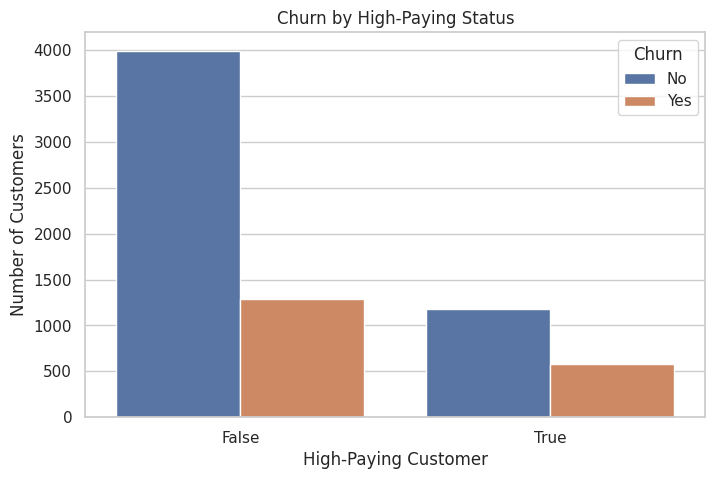

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='HighPaying', hue='Churn')
plt.title('Churn by High-Paying Status')
plt.xlabel('High-Paying Customer')
plt.ylabel('Number of Customers')
plt.show()

### Analysis

High-paying customers (True) represent the top 25% of monthly charges.  
From the plot, we can observe whether these high-value customers are more likely to churn compared to others.

2. Contract vs Churn for High-Paying Customers

This plot analyzes the relationship between contract type and churn specifically for high-paying customers.  
It helps the business understand which contract types among top-paying customers are more likely to leave.

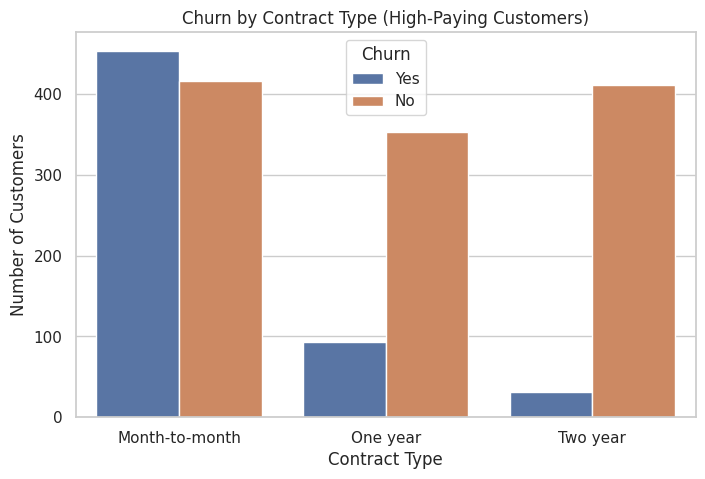

In [14]:
df_high = df[df['HighPaying'] == True]
plt.figure(figsize=(8,5))
sns.countplot(data=df_high, x='Contract', hue='Churn')
plt.title('Churn by Contract Type (High-Paying Customers)')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

### Analysis

Among high-paying customers:  
- Month-to-month contracts have the highest churn rate.  
- Customers with one-year or two-year contracts are more loyal.  

Insight: Retention strategies should target high-paying customers on month-to-month contracts to reduce churn.

3. Tenure vs Churn for High-Paying Customers

This plot examines the relationship between tenure and churn among high-paying customers.  
It helps us identify if newer high-paying customers are more likely to leave compared to long-term ones.

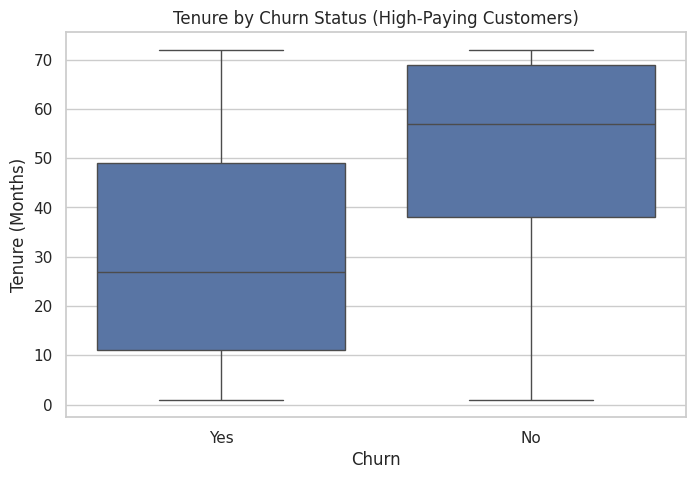

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_high, x='Churn', y='tenure')
plt.title('Tenure by Churn Status (High-Paying Customers)')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')
plt.show()

### Analysis

Among high-paying customers:  
- Customers who churn (Yes) tend to have shorter tenure.  
- Long-term high-paying customers are more loyal.  

Insight: Retention efforts should prioritize **new high-paying customers** to reduce early churn.

##  Feature Encoding (Data Preparation for Machine Learning)

Before training machine learning models, we need to convert categorical features into numerical format.  
Machine learning algorithms cannot work directly with text values such as "Yes", "No", or contract types.

In this step:
- The target variable **Churn** is converted into binary values (Yes → 1, No → 0).
- Categorical features are transformed into numerical features using one-hot encoding.
- The dataset becomes fully numerical and ready for model training.

In [16]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [17]:
df = df.drop('customerID', axis=1)

In [18]:
df_encoded = pd.get_dummies(df, drop_first=True)

##  Train–Test Split

In this step, we split the data into **training** and **testing** sets.
This allows us to evaluate how well our machine learning models perform on unseen data.

We will prepare:
- A **General Model** trained on all customers
- A **Specialized Model** trained only on High-Paying customers

### General Model – All Customers

This model learns churn behavior using the entire customer dataset.

In [19]:
# Features and target for general model
X_general = df_encoded.drop('Churn', axis=1)
y_general = df_encoded['Churn']

# Train-test split (80% train, 20% test)
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_general, y_general, test_size=0.2, random_state=42
)

### Specialized Model – High-Paying Customers

This model focuses only on customers who belong to the top 25% in MonthlyCharges.
The goal is to capture churn patterns specific to high-value customers.

In [20]:
# Filter High-Paying customers
df_high = df_encoded[df_encoded['HighPaying'] == 1]

# Features and target for specialized model
X_high = df_high.drop('Churn', axis=1)
y_high = df_high['Churn']

# Train-test split (80% train, 20% test)
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_high, y_high, test_size=0.2, random_state=42
)

### Why This Step Is Important

- The **training set** is used to teach the model.
- The **test set** is used to evaluate performance on unseen data.
- Having two splits allows us to compare:
  - General churn behavior
  - Churn behavior of high-paying customers specifically

#  Model Training

## 🧠 Objective
The objective of this step is to train supervised machine learning models to predict customer churn.

We build **two types of models**:
- **General Model**: trained on all customers
- **Specialized Model**: trained only on High-Paying customers

This allows us to compare customer behavior and understand whether high-value customers require a different churn strategy.

---

## 🔹 Models Used
In this project, we use the following supervised classification models:
- Logistic Regression
- Random Forest
- Gradient Boosting

These models are chosen to balance interpretability and performance.


---

## 🔹 1. Logistic Regression

### General Model

In [21]:
lr_general = LogisticRegression(max_iter=1000, random_state=42)
lr_general.fit(Xg_train, yg_train)

LogisticRegression(max_iter=1000, random_state=42)

### Specialized Model (High-Paying Customers)

In [22]:
lr_special = LogisticRegression(max_iter=1000, random_state=42)
lr_special.fit(Xh_train, yh_train)

LogisticRegression(max_iter=1000, random_state=42)

---

## 🔹 2. Random Forest

### General Model

In [23]:
rf_general = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_general.fit(Xg_train, yg_train)

RandomForestClassifier(random_state=42)

### Specialized Model (High-Paying Customers)

In [24]:
rf_special = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_special.fit(Xh_train, yh_train)

RandomForestClassifier(random_state=42)

---

## 🔹 3. Gradient Boosting

### General Model

In [25]:
gb_general = GradientBoostingClassifier(random_state=42)
gb_general.fit(Xg_train, yg_train)

GradientBoostingClassifier(random_state=42)

### Specialized Model (High-Paying Customers)

In [26]:
gb_special = GradientBoostingClassifier(random_state=42)
gb_special.fit(Xh_train, yh_train)

GradientBoostingClassifier(random_state=42)

---

## ✅ Summary
- All models are trained using supervised learning
- The same algorithms are applied to both datasets for fair comparison
- This step prepares the models for performance evaluation and business interpretation

➡️ Next Step: **Model Evaluation & Comparison**

# Model Evaluation

In this stage, we evaluate the performance of our Machine Learning models.
We assess both the **General Model** (trained on all customers) and the
**Specialized Model** (trained only on High-Paying Customers).

The goal is to understand:
- How well each model predicts churn
- Which model performs better for high-value customers
- Which features influence churn the most

## Evaluation Metrics

We use the following metrics to evaluate the models:

- **Accuracy**: Overall correctness of predictions  
- **Precision**: How many predicted churns are correct  
- **Recall**: How many actual churns are detected  
- **F1-score**: Balance between precision and recall  

Recall is especially important in churn prediction, as missing a churned
customer can result in revenue loss.

## Logistic Regression – General Model

This model provides a baseline performance and is easy to interpret.
It helps us understand the overall churn behavior of customers.

In [27]:
y_pred_lr_general = lr_general.predict(Xg_test)

print("Logistic Regression – General Model")
print(classification_report(yg_test, y_pred_lr_general))

Logistic Regression – General Model
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



## Random Forest – General Model

Random Forest is a more powerful model that captures non-linear
relationships and interactions between features.

In [28]:
y_pred_rf_general = rf_general.predict(Xg_test)

print("Random Forest – General Model")
print(classification_report(yg_test, y_pred_rf_general))

Random Forest – General Model
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1036
           1       0.67      0.47      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.79      0.80      0.79      1409



## Gradient Boosting – General Model

Gradient Boosting is an ensemble learning method that builds models
sequentially, where each new model focuses on correcting the errors
of the previous ones.

This model often achieves high performance on structured tabular data
and is well-suited for churn prediction.

In [29]:
y_pred_gb_general = gb_general.predict(Xg_test)

print("Gradient Boosting – General Model")
print(classification_report(yg_test, y_pred_gb_general))

Gradient Boosting – General Model
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.67      0.54      0.60       373

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Logistic Regression – High-Paying Customers

This model focuses only on high-paying customers.
Predicting churn accurately in this group is critical due to their
higher business value.

In [30]:
y_pred_lr_high = lr_special.predict(Xh_test)

print("Logistic Regression – High-Paying")
print(classification_report(yh_test, y_pred_lr_high))

Logistic Regression – High-Paying
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       220
           1       0.65      0.56      0.60       132

    accuracy                           0.72       352
   macro avg       0.70      0.69      0.69       352
weighted avg       0.72      0.72      0.72       352



## Random Forest – High-Paying Customers

This specialized model is trained only on high-paying customers
to capture churn patterns specific to this segment.

In [31]:
y_pred_rf_high = rf_special.predict(Xh_test)

print("Random Forest – High-Paying")
print(classification_report(yh_test, y_pred_rf_high))

Random Forest – High-Paying
              precision    recall  f1-score   support

           0       0.72      0.85      0.78       220
           1       0.65      0.46      0.54       132

    accuracy                           0.70       352
   macro avg       0.69      0.66      0.66       352
weighted avg       0.70      0.70      0.69       352



## Gradient Boosting – High-Paying Customers

This specialized Gradient Boosting model is trained only on
high-paying customers to capture complex churn patterns
specific to this high-value segment.

In [32]:
y_pred_gb_high = gb_special.predict(Xh_test)

print("Gradient Boosting – High-Paying")
print(classification_report(yh_test, y_pred_gb_high))

Gradient Boosting – High-Paying
              precision    recall  f1-score   support

           0       0.72      0.85      0.78       220
           1       0.63      0.45      0.52       132

    accuracy                           0.70       352
   macro avg       0.68      0.65      0.65       352
weighted avg       0.69      0.70      0.68       352



## Model Performance Summary

The table below summarizes the performance of the trained models.  
The positive class of interest is **Churn = 1**, since correctly identifying customers who are likely to leave is the main business objective.

| Dataset        | Model               | Accuracy | Precision (Churn=1) | Recall (Churn=1) | F1-score (Churn=1) |
|----------------|---------------------|----------|---------------------|------------------|--------------------|
| General        | Logistic Regression | 0.82     | 0.69                | 0.60             | 0.64               |
| General        | Random Forest       | 0.80     | 0.67                | 0.47             | 0.55               |
| General        | Gradient Boosting   | 0.81     | 0.67                | 0.54             | 0.60               |
| High-Paying    | Logistic Regression | 0.72     | 0.65                | 0.56             | 0.60               |
| High-Paying    | Random Forest       | 0.70     | 0.65                | 0.46             | 0.54               |
| High-Paying    | Gradient Boosting   | 0.70     | 0.63                | 0.45             | 0.52               |

---

## Insights & Conclusions

### 1. Best Overall Model
Logistic Regression shows the most balanced performance for both:
- General customers
- High-paying customers

It achieves the highest **F1-score** and **Recall** for churn, which is critical since the main goal is to detect as many customers at risk of leaving as possible.

---

### 2. Random Forest & Gradient Boosting
Although these models achieve good accuracy, their **recall for churn is relatively low**.  
This means they miss a significant number of customers who actually churn.

In churn prediction, **false negatives are costly**, since losing a customer without detection prevents any retention action.

---

### 3. General vs High-Paying Customers
Model performance consistently drops for high-paying customers across all models.

Possible reasons include:
- Smaller dataset size
- More complex and heterogeneous behavior among high-paying customers

This suggests that high-paying customers may require:
- Additional features
- More specialized modeling approaches

---

### 4. Business Insight
From a business perspective, **Logistic Regression is currently the most suitable model** for churn prediction.

It offers:
- Good interpretability
- Better ability to detect churn compared to other models

This makes it a strong baseline for designing customer retention strategies, especially when targeting high-value customers.

# Feature Importance & Interpretation
## Feature Importance  – General Model

Feature importance helps us understand which variables have the
strongest impact on churn prediction in the general customer base.

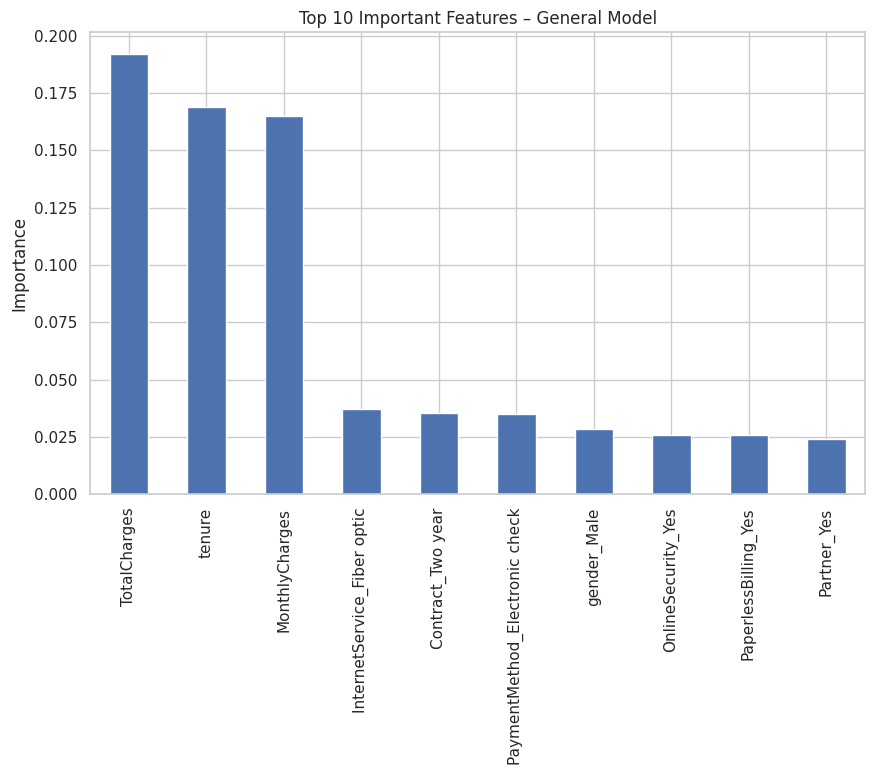

In [33]:

feature_importance_general = pd.Series(
    rf_general.feature_importances_,
    index=Xg_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance_general.head(10).plot(kind='bar')
plt.title("Top 10 Important Features – General Model")
plt.ylabel("Importance")
plt.show()



The feature importance analysis of the general churn model highlights the main factors influencing customer churn across all customer segments.

The most influential features are **TotalCharges**, **tenure**, and **MonthlyCharges**, indicating that customer lifetime value, relationship duration, and pricing play a central role in churn behavior.

Contract-related features, especially **two-year contracts**, strongly reduce churn, confirming that long-term commitments improve customer retention.

Service-related variables such as **InternetService (Fiber optic)** and **Online Security** also appear as important drivers, suggesting that service type and added services impact customer loyalty.

Finally, **Electronic check** as a payment method is associated with higher churn risk, which may reflect lower customer engagement or convenience issues.

## Feature Importance – High-Paying Customers

This plot highlights the most important churn drivers
specifically for high-paying customers.

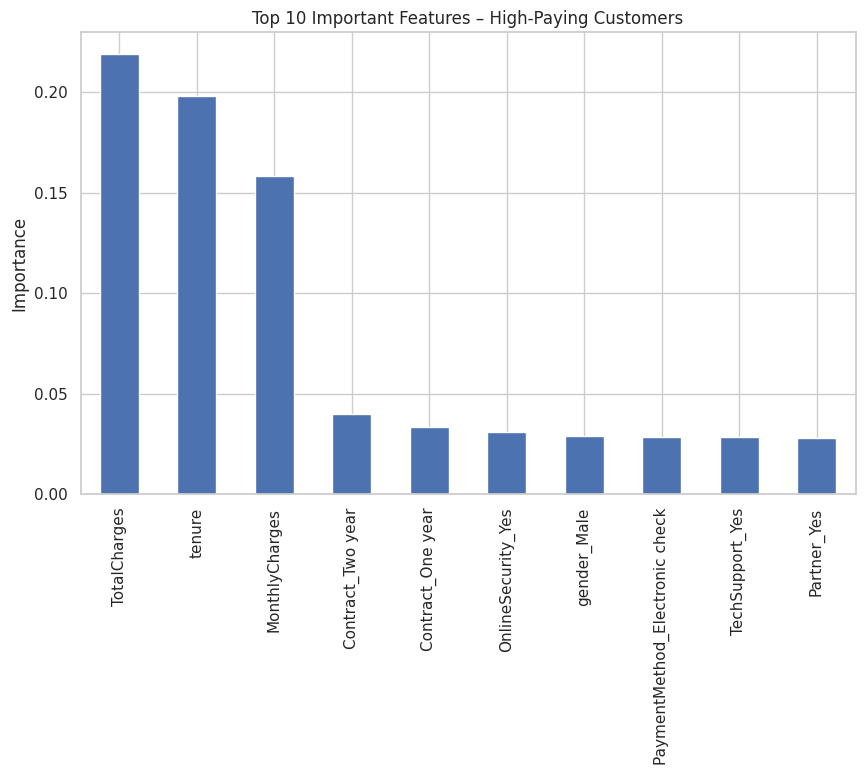

In [34]:
feature_importance_high = pd.Series(
    rf_special.feature_importances_,
    index=Xh_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance_high.head(10).plot(kind='bar')
plt.title("Top 10 Important Features – High-Paying Customers")
plt.ylabel("Importance")
plt.show()



The Random Forest model highlights the most influential features affecting churn among high-paying customers.

- **TotalCharges** and **tenure** are the strongest predictors, showing that both customer lifetime value and relationship duration are critical.
- **MonthlyCharges** remain important, indicating that higher prices can increase churn risk if perceived value is low.
- **Contract length** (One year, Two year) strongly reduces churn, even for high-paying customers.
- **Value-added services** such as Online Security and Tech Support significantly lower churn probability.
- **Payment method**, especially Electronic Check, is associated with higher churn behavior.

These results show that churn among high-paying customers is driven more by value perception and commitment rather than price alone.

## Comparison: General Model vs High-Paying Customer Model

The comparison between the general churn model and the high-paying customer model reveals both shared and segment-specific churn drivers.

In both models, **TotalCharges** and **tenure** remain the most important predictors, highlighting the importance of customer value and relationship duration regardless of customer segment.

However, notable differences emerge:
- In the general model, **Internet service type (Fiber optic)** plays a significant role, while it is less relevant for high-paying customers.
- For high-paying customers, **value-added services** such as Online Security and Tech Support become more influential.
- Pricing-related features have a stronger impact in the high-paying segment, indicating higher sensitivity to perceived value.

These differences confirm that churn behavior is not uniform across customer segments.

## Business Interpretation

The general churn model suggests that customer retention strategies should focus on improving long-term engagement, encouraging longer contracts, and addressing high-risk payment methods.

In contrast, high-paying customers require a more personalized approach. Their churn is driven more by perceived value, service quality, and long-term relationship benefits rather than basic service type.

This demonstrates the importance of segment-specific churn models. A single general model provides a broad overview, but a specialized model for high-paying customers delivers actionable business insights that support targeted retention strategies and revenue protection.

# Conclusion & Recommendations

### Key Findings

This project combined a **general churn prediction model** with a **specialized model for high-paying customers**, allowing both a global and segment-specific understanding of churn behavior.

Across all customers, churn is mainly influenced by:
- Short customer tenure
- High MonthlyCharges
- Month-to-month contracts
- Electronic check payment method

For high-paying customers, churn behavior shows important differences:
- Tenure and TotalCharges remain critical, confirming the role of long-term relationships.
- Value-added services such as Online Security and Tech Support play a stronger role.
- Pricing sensitivity is higher, meaning perceived value is more important than basic service type.

These results confirm that churn drivers vary significantly by customer segment.

---

### Business Recommendations

**For the General Customer Base:**
- Encourage long-term contracts (one-year or two-year plans).
- Reduce churn risk for new customers through onboarding and early engagement.
- Review the customer experience for users paying via electronic check.

**For High-Paying Customers:**
- Focus on personalized retention strategies rather than generic discounts.
- Bundle premium services (Online Security, Tech Support) to increase perceived value.
- Proactively target high-paying customers with short tenure, as they represent the highest churn risk.

---

### Final Takeaway

Building a single general churn model provides a strong overview, but adding a **specialized model for high-paying customers delivers deeper business value**.

This project demonstrates how machine learning can support **data-driven decision-making**, optimize retention strategies, and protect high-revenue customers.

The combination of exploratory analysis, segmentation, and multiple supervised models makes this project **portfolio-ready** and relevant for real-world business applications.